In [1]:
%load_ext autoreload
%autoreload 2

import sys

PROJECT = "/Users/Guille/Desktop/dynamic_update/functional_forecast_dynamic_update"

sys.path.insert(0, PROJECT)

import datetime, calendar, glob, os, requests, pickle

import numpy as np
import pandas as pd

from src import loader, plotter
from src.config import VALIDATION, TABLES

# Formating tables in the paper

In [2]:
# def _envelop_table(resource, method, type, description, score, input_path):

#     hyper_ = pd.read_csv(input_path + f"/{resource}/{resource}_{method}_{type}-hyper-{description}.csv")
#     print(input_path + f"/{resource}/{resource}_{method}_{type}-hyper-{init}.csv")

#     times_ = np.sort(hyper_['time'].unique())
         
#     # choose the best initialization per time using the minimum KS_val
#     best_hyper_ = (hyper_
#         .loc[hyper_['time'].isin(times_)]
#         .sort_values(['time', 'KS_val'])
#         .groupby('time', as_index=False)
#         .first()[['time', 'initialization', 'KS_val']])
#     #print(best_hyper_)
#     envelop_ = pd.read_csv(input_path + f"/{resource}/{resource}_{method}_{type}-envelope-{description}.csv")
#     print(envelop_)

#     envelop_ = envelop_.loc[envelop_['score'] == score]
#     envelop_filtered_ = envelop_.merge(best_hyper_[['time', 'initialization']],
#                                        left_on=['time', 'iteration'],
#                                        right_on=['time', 'initialization'],
#                                        how='inner')
    
#     envelop_filtered_ = envelop_filtered_.drop(columns=['initialization', 
#                                                         'score', 
#                                                         'iteration']).reset_index(drop=True)
    
#     fraction_table_all_distances_ = envelop_filtered_.pivot(index=['alpha', 'distance'],
#                                                          columns='time',
#                                                          values='fraction')
#     #print(fraction_table_all_distances_.loc[fraction_table_all_distances_['distance'] == 'MBD'])

#     fraction_table_all_distances_.columns.name = None

#     # Average scores across times for each alpha and distance
#     avg_scores_ = envelop_.groupby(['alpha', 
#                                     'distance']).agg({'FCS': 'mean',
#                                                       'FIS': 'mean',
#                                                       'SCP': 'mean'}).reset_index(drop = False)
    
#     # optional: remove the column-axis name "time."
#     summary_ = fraction_table_all_distances_.merge(avg_scores_, 
#                                                    on=['alpha', 'distance'], 
#                                                    how='left').round(2)

#     # Rename row index labels for LaTeX
#     summary_ = summary_.set_index(['alpha', 'distance'])
#     summary_.index.names = [r'$\boldsymbol{\alpha}$', r'\textbf{Distance}']
#     summary_.columns = pd.MultiIndex.from_tuples([(r'\textbf{Time}', times_[0]),
#                                                   (r'\textbf{Time}', times_[1]),
#                                                   (r'\textbf{Time}', times_[2]),
#                                                   (r'\textbf{Score}', 'FCS'),
#                                                   (r'\textbf{Score}', 'FIS'),
#                                                   (r'\textbf{Score}', 'SCP')])
    
#     return summary_

In [3]:
# def _envelope_table(_init, hyper_, envelope_, score, PATH,
#     alphas = [0.1, 0.2]
#     ):
        
#     envelope_ = envelope_.reset_index(drop = False)
#     times = np.array(hyper_.columns)

#     envelope_ = pd.concat(
#         [envelope_.loc[envelope_['alpha'] == alpha] for alpha in alphas], axis = 0
#     )

#     fraction_table_ = (
#         envelope_
#         .pivot_table(
#             index=["alpha", "distance"],
#             columns="time",
#             values="fraction",
#             aggfunc="mean"
#         )
#         .reset_index()
#     )

#     fraction_table_.columns.name = None

#     # --------------------------------------------------
#     # 2. Add ECDF rows for scores only.
#     #    ECDF has no fraction, so time columns remain empty.
#     # --------------------------------------------------
#     ecdf_ = envelope_.loc[envelope_["distance"] == "ECDF"].copy()

#     score_rows_ = pd.concat(
#         [
#             envelope_[["time", "alpha", "distance", "FCS", "FIS", "SCP"]],
#             ecdf_[["time", "alpha", "distance", "FCS", "FIS", "SCP"]]
#         ], axis=0, ignore_index=True
#     )

#     avg_scores_ = (
#         score_rows_
#         .groupby(["alpha", "distance"], as_index=False)
#         .agg({
#             "FCS": "mean",
#             "FIS": "mean",
#             "SCP": "mean"
#         })
#     )

#     # Use avg_scores_ as the base so ECDF rows are preserved
#     summary_ = (
#         avg_scores_
#         .merge(fraction_table_, on=["alpha", "distance"], how="left")
#     )

#     # Put time columns before score columns
#     summary_ = summary_[
#         ["alpha", "distance"] + list(times) + ["FCS", "FIS", "SCP"]
#     ]

#     summary_ = summary_.round(2)

#     # Set row index for LaTeX
#     summary_ = summary_.set_index(["alpha", "distance"])

#     summary_.index.names = [
#         r"$\boldsymbol{\alpha}$",
#         r"\textbf{Method}"
#     ]

#     # MultiIndex columns
#     time_cols = [(r"\textbf{Time}", t) for t in times]
#     score_cols = [
#         (r"\textbf{Score}", "FCS"),
#         (r"\textbf{Score}", "FIS"),
#         (r"\textbf{Score}", "SCP")
#     ]

#     summary_.columns = pd.MultiIndex.from_tuples(time_cols + score_cols)

#     return summary_


# def envelope_table(_init, hyper_, envelope_, path_to_validation):
        
#     FCS_ = _envelope_table(
#         _init,
#         hyper_, 
#         envelope_, 
#         score = 'FCS',
#         PATH = path_to_validation,
#     )
    
#     FIS_ = _envelope_table(
#         _init,
#         hyper_, 
#         envelope_, 
#         score = 'FIS',
#         PATH = path_to_validation,
#     )
    
#     # Add top-level criterion headers
#     FIS_.columns = pd.MultiIndex.from_tuples(
#         [(r'\textbf{FIS criterion}', *col) for col in FIS_.columns]
#     )
    
#     FCS_.columns = pd.MultiIndex.from_tuples(
#         [(r'\textbf{FCS criterion}', *col) for col in FCS_.columns]
#     )
    
#     # Concatenate tables to the right
#     summary_ = pd.concat([FIS_, FCS_], axis=1)
#     # print(summary_)
    
#     # Generate latex code
#     latex_ = summary_.to_latex(
#         float_format="%.2f",
#         multirow=True,
#         multicolumn=True,
#         column_format="l|l|ccc|ccc|ccc|ccc",
#         escape=False
#     )
    
#     latex_ = latex_.replace('l2', r'$\ell_2$')
#     latex_ = latex_.replace('F', r'')
#     latex_ = latex_.replace('fknn', r'$\omega_i (f_\star, e_\star)$')
#     latex_ = latex_.replace('sup', r'$\sup$')
    
#     return summary_, latex_

In [5]:
# wind unbiased-025-0 {6: 1, 12: 2, 18: 2}
# wind unbiased-025-1 {6: 1, 12: 4, 18: 1}
# wind unbiased-025-2 {6: 2, 12: 1, 18: 1}
# wind biased-025 {6: 4, 12: 4, 18: 4}

_init = {6: 1, 12: 4, 18: 5}

# solar asset
method = 'fusion'
resource = 'wind'
aggregation = 'zone'
exp_description = 'unbiased-025-1'

hyper_, envelope_ = loader.hyperparameters(
    _init,
    resource,
    method,
    aggregation,
    exp_description=exp_description,
    path_to_validation=VALIDATION,
)

table, latex = loader.envelope_table(
    _init, 
    hyper_, 
    envelope_, 
    path_to_validation=VALIDATION
)
# print(table)

file_name = TABLES / f"{resource}_{method}_{aggregation}_{exp_description}-envelope.tex"
with open(file_name, "w") as _f:
    _f.write(latex)

/Users/Guille/Desktop/dynamic_update/functional_forecast_dynamic_update/src/loader.py:200: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_ = summary_.to_latex(


In [9]:

FIS_summary_ = envelope_table(resource, method, type, 
                              description = 1, 
                              score = 'FIS', 
                              input_path = path_to_validation)

# Add top-level criterion headers
FIS_summary_.columns = pd.MultiIndex.from_tuples([(r'\textbf{FIS criterion}', *col) 
                                                  for col in FIS_summary_.columns])

FCS_summary_.columns = pd.MultiIndex.from_tuples([(r'\textbf{FCS criterion}', *col) 
                                                  for col in FCS_summary_.columns])

# Concatenate tables to the right
summary_ = pd.concat([FIS_summary_, FCS_summary_], axis=1)
print(summary_)

# Generate latex code
latex_ = summary_.to_latex(float_format="%.2f",
                           multirow=True,
                           multicolumn=True,
                           column_format="l|l|ccc|ccc|ccc|ccc",
                           escape=False)

latex_ = latex_.replace('l2', r'$\ell_2$')
latex_ = latex_.replace('F', r'')
latex_ = latex_.replace('fknn', r'$\omega_i (f_\star, e_\star)$')
latex_ = latex_.replace('sup', r'$\sup$')

file_name = 
with open(TABLES / f"{resource}_{method}_{type}-envelop.tex", "w") as _f:
    _f.write(latex_)


SyntaxError: invalid syntax (1139092619.py, line 29)

In [5]:
# wind region
resource = 'wind'
method = 'fusion'
type = 'zone' 

FIS_summary_ = _envelop_table(resource, method, type,  
                              description = 11, 
                              score = 'FCS', 
                              input_path = path_to_validation)

FCS_summary_ = _envelop_table(resource, method, type,  
                              description = 11, 
                              score = 'FCS', 
                              input_path = path_to_validation)

# Add top-level criterion headers
FIS_summary_.columns = pd.MultiIndex.from_tuples([(r'\textbf{FIS criterion}', *col) 
                                                  for col in FIS_summary_.columns])

FCS_summary_.columns = pd.MultiIndex.from_tuples([(r'\textbf{FCS criterion}', *col) 
                                                  for col in FCS_summary_.columns])

# Concatenate tables to the right
summary_ = pd.concat([FIS_summary_, FCS_summary_], axis=1)
print(summary_)

# Generate latex code
latex_ = summary_.to_latex(float_format="%.2f",
                           multirow=True,
                           multicolumn=True,
                           column_format="l|l|ccc|ccc|ccc|ccc",
                           escape=False)

latex_ = latex_.replace('l2', r'$\ell_2$')
latex_ = latex_.replace('F', r'')
latex_ = latex_.replace('fknn', r'$\omega_i (f_\star, e_\star)$')
latex_ = latex_.replace('sup', r'$\sup$')

file_name = path_to_tables + f"/{resource}_{method}_{type}-envelop.tex"
with open(file_name, "w") as _f:
    _f.write(latex_)
print(file_name)

                                      \textbf{FIS criterion}              \
                                               \textbf{Time}               
                                                           6    12    18   
$\boldsymbol{\alpha}$ \textbf{Method}                                      
0.1                   ECDF                               NaN   NaN   NaN   
                      MBD                               0.60  0.60  0.60   
                      fknn                              0.60  0.60  0.60   
                      l2                                0.60  0.65  0.65   
                      sup                               0.60  0.60  0.60   
0.2                   ECDF                               NaN   NaN   NaN   
                      MBD                               0.35  0.40  0.40   
                      fknn                              0.40  0.40  0.40   
                      l2                                0.40  0.40  0.40   
            

/var/folders/0c/ffx2kgyn7xq4krqrpsv67l3m0000gn/T/ipykernel_43798/1900036336.py:28: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_ = summary_.to_latex(float_format="%.2f",


In [6]:
# wind asset
resource = 'wind'
method = 'fusion'
type = 'asset'

FCS_summary_ = _envelop_table(resource, method, type, 
                              description = 5, 
                              score = 'FCS', 
                              input_path = path_to_validation)

FIS_summary_ = _envelop_table(resource, method, type,
                              description = 5, 
                              score = 'FIS', 
                              input_path = path_to_validation)

# Add top-level criterion headers
FIS_summary_.columns = pd.MultiIndex.from_tuples([(r'\textbf{FIS criterion}', *col) 
                                                  for col in FIS_summary_.columns])

FCS_summary_.columns = pd.MultiIndex.from_tuples([(r'\textbf{FCS criterion}', *col) 
                                                  for col in FCS_summary_.columns])

# Concatenate tables to the right
summary_ = pd.concat([FIS_summary_, FCS_summary_], axis=1)
print(summary_)

# Generate latex code
latex_ = summary_.to_latex(float_format="%.2f",
                           multirow=True,
                           multicolumn=True,
                           column_format="l|l|ccc|ccc|ccc|ccc",
                           escape=False)

latex_ = latex_.replace('l2', r'$\ell_2$')
latex_ = latex_.replace('F', r'')
latex_ = latex_.replace('fknn', r'$\omega_i (f_\star, e_\star)$')
latex_ = latex_.replace('sup', r'$\sup$')

file_name = path_to_tables + f"/{resource}_{method}_{type}-envelop.tex"
with open(file_name, "w") as _f:
    _f.write(latex_)
print(file_name)

                                      \textbf{FIS criterion}              \
                                               \textbf{Time}               
                                                          72   144   216   
$\boldsymbol{\alpha}$ \textbf{Method}                                      
0.1                   ECDF                               NaN   NaN   NaN   
                      MBD                               0.75  0.70  0.75   
                      fknn                              0.85  0.80  0.75   
                      l2                                0.80  0.75  0.85   
                      sup                               0.80  0.75  0.85   
0.2                   ECDF                               NaN   NaN   NaN   
                      MBD                               0.50  0.50  0.55   
                      fknn                              0.55  0.60  0.55   
                      l2                                0.50  0.55  0.60   
            

/var/folders/0c/ffx2kgyn7xq4krqrpsv67l3m0000gn/T/ipykernel_43798/3017413392.py:28: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_ = summary_.to_latex(float_format="%.2f",


# Validated hyperparameters

In [41]:
# Get optimal hyperparameters and envelope samples from cross-validation results
def _load_hyperparamerters(resource, method, type, score, description, path):

    hyper_base_ = pd.read_csv(path + f"/{resource}/{resource}_{method}_{type}-hyper-base.csv")
    hyper_val_ = pd.read_csv(path + f"/{resource}/{resource}_{method}_{type}-hyper-{description}.csv")
    envelope_val_ = pd.read_csv(path + f"/{resource}/{resource}_{method}_{type}-envelope-{description}.csv")

    hyper_val_ = hyper_val_.loc[hyper_val_.groupby('time')['KS_val'].idxmin(), 
                                ['time', 'initialization'] + list(hyper_val_.columns[-15:])]

    hyper_ = hyper_val_.set_index('time').T
    hyper_.index.name = 'parameter'
    hyper_ = hyper_.drop(index=['initialization', 'KS_val'])

    
    # Make sure interval columns have the same type
    hyper_base_updated_ = hyper_base_.set_index("parameter").copy()
    hyper_base_updated_.columns = hyper_base_updated_.columns.astype(int)
    hyper_.columns = hyper_.columns.astype(int)

    # Align hyper_ to the same index/columns as hyper_base_
    hyper_aligned_ = hyper_.reindex(index=hyper_base_updated_.index,
                                    columns=hyper_base_updated_.columns)
    
    # Overwrite values in hyper_base_ with values from hyper_
    # for all matching parameters and intervals
    hyper_base_updated_.update(hyper_aligned_)
    
    # Optional: bring parameter back as a column
    hyper_base_updated_ = hyper_base_updated_.reset_index()

    envelope_ = []
    for time, init in zip(hyper_val_['time'], hyper_val_['initialization']):
        idx_ = ((envelope_val_['time'] == time) 
                & (envelope_val_['iteration'] == init)
                & (envelope_val_['score'] == score))
        envelope_.append(envelope_val_.loc[idx_, ['time', 'alpha', 'fraction', 'distance']])
    
    envelope_ = pd.concat(envelope_, axis = 0).set_index('time')
    
    return hyper_base_updated_, envelope_, hyper_val_

# wind asset
resource = 'solar'
method = 'fusion'
type = 'asset'
description = 1
score = 'FCS'

hyper_, envelope_, validation_ = _load_hyperparamerters(resource, method, type, score, description, 
                                                        path = path_to_validation)

hyper_.to_csv(path_to_validation + f"/{resource}/{resource}_{method}_{type}-hyper-base.csv", index = False)
validation_.to_csv(path_to_validation + f"/{resource}/{resource}_{method}_{type}-validation-base.csv", index = True)
envelope_.to_csv(path_to_validation + f"/{resource}/{resource}_{method}_{type}-envelope-base.csv", index = True)
print(validation_)
print(envelope_)

# wind asset
resource = 'wind'
method = 'fusion'
type = 'asset'
description = 5
score = 'FCS'

hyper_, envelope_, validation_ = _load_hyperparamerters(resource, method, type, score, description, 
                                                        path = path_to_validation)

hyper_.to_csv(path_to_validation + f"/{resource}/{resource}_{method}_{type}-hyper-base.csv", index = False)
validation_.to_csv(path_to_validation + f"/{resource}/{resource}_{method}_{type}-validation-base.csv", index = True)
envelope_.to_csv(path_to_validation + f"/{resource}/{resource}_{method}_{type}-envelope-base.csv", index = True)
print(hyper_)

# wind zone
resource = 'wind'
method = 'fusion'
type = 'zone'
description = 11
score = 'FCS'

hyper_, envelope_, validation_ = _load_hyperparamerters(resource, method, type, score, description, 
                                                        path = path_to_validation)

hyper_.to_csv(path_to_validation + f"/{resource}/{resource}_{method}_{type}-hyper-base.csv", index = False)
validation_.to_csv(path_to_validation + f"/{resource}/{resource}_{method}_{type}-validation-base.csv", index = True)
envelope_.to_csv(path_to_validation + f"/{resource}/{resource}_{method}_{type}-envelope-base.csv", index = True)
print(hyper_)

    time  initialization    KS_val   ES_test  WIS_test   KS_test   S0_test  \
2    120               2  0.037635  1.279197  8.070940  0.031984  0.024097   
5    144               1  0.031556  1.046566  5.852204  0.036845  0.042437   
12   168               4  0.032369  0.873507  4.153348  0.040641  0.043241   

     S1_test   S2_test   S3_test   S4_test   S5_test  forget_rate_f  \
2   0.033935  0.031499  0.030995  0.034236  0.037139       2.000000   
5   0.039877  0.025062  0.033467  0.033735  0.046494       0.230896   
12  0.035139  0.024213  0.031944  0.045190  0.064120       2.000000   

    forget_rate_e  length_scale_f  length_scale_e  trust_rate  
2             1.0        0.121431        1.460833    0.145592  
5            10.0        0.088152        1.185769    0.100000  
12           10.0        0.201965        5.000000    0.100000  
      alpha  fraction distance
time                          
120     0.1      0.70      MBD
120     0.2      0.45      MBD
120     0.3      0.30 

# Samples for figures in the paper

In [8]:
# # wind asset
# intervals_ = [72, 144, 216]
# resource = 'wind'
# method = 'fusion'
# type = 'asset'
# description = '5'
# score = 'FCS'
# T = 288

# hyper_, envelope_, hyper_meta_ = _load_hyperparamerters(resource, method, type, score, description, 
#                                                         path = path_to_validation)
# print(hyper_meta_)

# # first interval
# file_name = path_to_validation + f"/{resource}/{resource}_{method}_{type}-STATS_{intervals_[0]}-{description}.csv"
# init = hyper_meta_.loc[hyper_meta_['time'] == intervals_[0], 'initialization'].values[0]

# stats_1_ = pd.read_csv(file_name)
# stats_1_ = stats_1_.loc[stats_1_['initialization'] == init].reset_index(drop = True)
# #stats_1_[intervals_[0]] = np.median(stats_1_[stats_1_.columns[:(T - intervals_[0])]].to_numpy(), axis = 1)
# #stats_1_[intervals_[0]] = np.mean(stats_1_[stats_1_.columns[:(T - intervals_[0])]].to_numpy(), axis = 1)
# stats_1_[intervals_[0]] = np.max(stats_1_[stats_1_.columns[:(T - intervals_[0])]].to_numpy(), axis = 1)
# stats_1_ = stats_1_[['region', 'day', intervals_[0]]]
# stats_1_['region'] = stats_1_['region'].astype(int)
# stats_1_['day'] = stats_1_['day'].astype(int)
# print(stats_1_)

# # Middle interval
# file_name = path_to_validation + f"/{resource}/{resource}_{method}_{type}-STATS_{intervals_[1]}-{description}.csv"
# init = hyper_meta_.loc[hyper_meta_['time'] == intervals_[1], 'initialization'].values[0]

# stats_2_ = pd.read_csv(file_name)
# stats_2_ = stats_2_.loc[stats_2_['initialization'] == init].reset_index(drop = True)
# #stats_2_[intervals_[1]] = np.median(stats_2_[stats_2_.columns[:(T - intervals_[1])]].to_numpy(), axis = 1)
# #stats_2_[intervals_[1]] = np.mean(stats_2_[stats_2_.columns[:(T - intervals_[1])]].to_numpy(), axis = 1)
# stats_2_[intervals_[1]] = np.max(stats_2_[stats_2_.columns[:(T - intervals_[1])]].to_numpy(), axis = 1)
# stats_2_ = stats_2_[['region', 'day', intervals_[1]]]
# stats_2_['region'] = stats_2_['region'].astype(int)
# stats_2_['day'] = stats_2_['day'].astype(int)
# print(stats_2_)

# # Last interval
# file_name = path_to_validation + f"/{resource}/{resource}_{method}_{type}-STATS_{intervals_[2]}-{description}.csv"
# init = hyper_meta_.loc[hyper_meta_['time'] == intervals_[2], 'initialization'].values[0]

# stats_3_ = pd.read_csv(file_name)
# stats_3_ = stats_3_.loc[stats_3_['initialization'] == init].reset_index(drop = True)
# #stats_3_[intervals_[2]] = np.median(stats_3_[stats_3_.columns[:(T - intervals_[2])]].to_numpy(), axis = 1)
# #stats_3_[intervals_[2]] = np.mean(stats_3_[stats_3_.columns[:(T - intervals_[2])]].to_numpy(), axis = 1)
# stats_3_[intervals_[2]] = np.max(stats_3_[stats_3_.columns[:(T - intervals_[2])]].to_numpy(), axis = 1)
# stats_3_ = stats_3_[['region', 'day', intervals_[2]]]
# stats_3_['region'] = stats_3_['region'].astype(int)
# stats_3_['day'] = stats_3_['day'].astype(int)
# print(stats_3_)

# stats_ = stats_1_.merge(stats_2_, on = ['region', 'day'], how = 'left')
# stats_ = stats_.merge(stats_3_, on = ['region', 'day'], how = 'left')
# print(stats_)

In [9]:
def _load_asset_stats(validation_, intervals_, resource, method, type, description, T, path, 
                      agg="max"):
    """
    Load STATS files for each interval, select the optimal initialization,
    aggregate across horizon columns, and merge all intervals by region/day.

    agg options: "max", "mean", "median"
    """
    agg_funcs = {"max": np.max,
                 "mean": np.mean,
                 "median": np.median}

    stats_list_ = []

    for interval in intervals_:
        
        stats_ = pd.read_csv(path + f"/{resource}/{resource}_{method}_{type}-STATS_{interval}-{description}.csv")
        print(interval, stats_.shape)
        init = validation_.loc[validation_["time"] == interval, "initialization"].values[0]
        stats_ = stats_.loc[stats_["initialization"] == init].reset_index(drop=True)

        # Aggregate over the first T - interval columns
        stats_[interval] = agg_funcs[agg](stats_[stats_.columns[:(T - interval)]].to_numpy(), axis=1)
        stats_ = stats_[["region", "day", interval]].copy()
        stats_["region"] = stats_["region"].astype(int)
        stats_["day"] = stats_["day"].astype(int)

        stats_list_.append(stats_)
        
    stats_ = stats_list_[0].merge(stats_list_[1], on=["region", "day"], how="left")
    stats_ = stats_.merge(stats_list_[2], on=["region", "day"], how="left")

    return stats_

# solar asset
intervals_ = [120, 144, 168]
resource = 'solar'
description = 1

# wind asset
# intervals_ = [72, 144, 216]
# resource = 'wind'
# description = 5

method = 'fusion'
type = 'asset'
score = 'FCS'
T = 288

hyper_, envelope_, validation_ = _load_hyperparamerters(resource, method, type, score, description, 
                                                        path = path_to_validation)
print(hyper_)
stats_ = _load_asset_stats(validation_, intervals_, resource, method, type, description, T, 
                           agg="max",
                           path = path_to_validation)
print(stats_)

         parameter         120         144         168
0    forget_rate_f    2.000000    0.230896    2.000000
1    forget_rate_e    1.000000   10.000000   10.000000
2      lookup_rate   10.000000   10.000000   10.000000
3   length_scale_f    0.121431    0.088152    0.201965
4   length_scale_e    1.460833    1.185769    5.000000
5       trust_rate    0.145592    0.100000    0.100000
6               nu    6.000000    6.000000    6.000000
7               xi    0.650000    0.650000    0.650000
8            gamma   45.000000   45.000000   45.000000
9            kappa  150.000000  150.000000  150.000000
10        p_fusion    0.500000    0.500000    0.500000
120 (432000, 172)
144 (432000, 148)
168 (432000, 124)
          region  day       120       144       168
0             10    0  0.284624  0.292525  0.288964
1             10    0  0.284624  0.292525  0.288964
2             10    0  0.284624  0.292525  0.288964
3             10    0  0.284624  0.292525  0.288964
4             10    0  0.2

In [10]:
# The same region, different day, for a given interval (eg, 144), low and high scores.
interval = intervals_[1]   # or "144" if your columns are strings
df_score = stats_.copy()

# Lowest score day for each region
idx_low = df_score.groupby("region")[interval].idxmin()
low_df = df_score.loc[idx_low].rename(columns={"day": "low_day", interval: "low_score"})
low_df = low_df[["region", "low_day", "low_score"]]
print(low_df.shape)

# Highest score day for each region
idx_high = df_score.groupby("region")[interval].idxmax()
high_df = df_score.loc[idx_high].rename(columns={"day": "high_day", interval: "high_score"})
high_df = high_df[["region", "high_day", "high_score"]]
print(high_df.shape)

summary = low_df.merge(high_df, on="region")
summary["difference"] = summary["high_score"] - summary["low_score"]
summary = summary.sort_values("region", ascending=False).reset_index(drop=True)
print(summary)

(10, 3)
(10, 3)
   region  low_day  low_score  high_day  high_score  difference
0      19      178   0.126137       163    0.369781    0.243644
1      18      178   0.065473       138    0.338458    0.272985
2      17      329   0.118517        50    0.324595    0.206078
3      16      178   0.065686       139    0.352665    0.286979
4      15      178   0.064477       114    0.353809    0.289333
5      14      329   0.085874        52    0.379148    0.293273
6      13      162   0.106317        57    0.367664    0.261347
7      12      170   0.134048       114    0.354178    0.220130
8      11      182   0.107938        57    0.368352    0.260414
9      10      163   0.117019        61    0.336966    0.219946


In [ ]:
# The same region, same day, growing scores across intervals (72, 144, 216).
df_score = stats_.copy()

# Strictly decreasing score
growing_df = df_score[((df_score[intervals_[0]] >= df_score[intervals_[1]]) 
                       & (df_score[intervals_[1]] >= df_score[intervals_[2]]))].copy()

growing_df["increase_1"] = growing_df[intervals_[0]] - growing_df[intervals_[1]]
growing_df["increase_2"] = growing_df[intervals_[1]] - growing_df[intervals_[2]]
growing_df["increase"]   = growing_df[["increase_1", "increase_2"]].min(axis=1)

growing_df = growing_df.sort_values("increase", ascending=False).reset_index(drop=True)

print(growing_df)

In [11]:
# The same region, same day, growing scores across intervals (72, 144, 216).
df_score = stats_.copy()

# Strictly decreasing score
growing_df = df_score[((df_score[intervals_[0]] >= df_score[intervals_[1]]) 
                       & (df_score[intervals_[1]] >= df_score[intervals_[2]]))].copy()

growing_df["increase_1"] = growing_df[intervals_[0]] - growing_df[intervals_[1]]
growing_df["increase_2"] = growing_df[intervals_[1]] - growing_df[intervals_[2]]
growing_df["increase"]   = growing_df[["increase_1", "increase_2"]].min(axis=1)

growing_df = growing_df.sort_values("increase", ascending=False).reset_index(drop=True)

print(growing_df)

          region  day       120       144       168  increase_1  increase_2  \
0             17  357  0.318999  0.257741  0.133847    0.061259    0.123894   
1             17  357  0.318999  0.257741  0.133847    0.061259    0.123894   
2             17  357  0.318999  0.257741  0.133847    0.061259    0.123894   
3             17  357  0.318999  0.257741  0.133847    0.061259    0.123894   
4             17  357  0.318999  0.257741  0.133847    0.061259    0.123894   
...          ...  ...       ...       ...       ...         ...         ...   
13298683      18  139  0.357380  0.335381  0.335375    0.021998    0.000006   
13298684      18  139  0.357380  0.335381  0.335375    0.021998    0.000006   
13298685      18  139  0.357380  0.335381  0.335375    0.021998    0.000006   
13298686      18  139  0.357380  0.335381  0.335375    0.021998    0.000006   
13298687      18  139  0.357380  0.335381  0.335375    0.021998    0.000006   

          increase  
0         0.061259  
1        

In [12]:
# Two regions, same day, low and high scores for the same interval (eg, 144).
df_score = stats_.copy()
interval = intervals_[1]

# Lowest-score region for each day
idx_low = df_score.groupby("day")[interval].idxmin()

# Highest-score region for each day
idx_high = df_score.groupby("day")[interval].idxmax()

low_df = df_score.loc[idx_low].rename(columns={"region": "low_region", interval: "low_score"})
low_df = low_df[["day", "low_region", "low_score"]]

high_df = df_score.loc[idx_high].rename(columns={"region": "high_region", interval: "high_score"})
high_df = high_df[["day", "high_region", "high_score"]]

summary = low_df.merge(high_df, on="day")
summary["difference"] = summary["high_score"] - summary["low_score"]
summary = summary.sort_values("difference", ascending=False).reset_index(drop=True)
print(summary)

     day  low_region  low_score  high_region  high_score  difference
0    164          11   0.108054           19    0.369472    0.261418
1    163          11   0.116092           19    0.369781    0.253690
2    162          13   0.106317           19    0.356965    0.250648
3    161          13   0.109109           19    0.351768    0.242659
4    181          11   0.109345           19    0.347788    0.238443
..   ...         ...        ...          ...         ...         ...
355  146          14   0.235789           17    0.274013    0.038224
356  340          16   0.167346           13    0.204163    0.036817
357  289          15   0.279051           19    0.314076    0.035025
358  145          10   0.240378           16    0.275391    0.035013
359  356          19   0.178545           17    0.194831    0.016287

[360 rows x 6 columns]


# PIT

In [25]:
def _load_pit(hyper_meta_, resource, method, type, interval, description, path):
    
    pit_ = pd.read_csv(path + f"/{resource}/{resource}_{method}_{type}-PIT_{interval}-{description}.csv")
    
    init = hyper_meta_.loc[hyper_meta_['time'] == interval, 'initialization'].values[0]
    pit_ = pit_.loc[pit_['initialization'] == init].reset_index(drop = True)

    return pit_.drop(columns = ['initialization', 'time']).to_numpy()

def clean_fmt(x, pos):
    if abs(x - round(x)) < 1e-9:
        return str(int(round(x)))
    return f"{x:.2g}"

def _plot_PIT(_ax, u_, 
              bins=10,
              v=0.5,
              xlabel = 'PIT'):
    
    vmin= -v
    vmax= v
    
    KS_stat = _KS(u_)
    u_ = np.sort(u_)
    n = len(u_)

    # --- Histogram ---
    counts_, bins_, patches = _ax.hist(u_,
                                       bins=bins,
                                       range=(0.0, 1.0),
                                       density=True,
                                       lw=0.5,
                                       edgecolor='k',
                                       alpha=1)

    # deviation from perfect calibration
    deviation = counts_ - 1.
    #print(deviation.min(), deviation.max())
    #print(deviation)
    
    # --- Colormap centered at 0 ---
    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    cmap = cm.get_cmap("coolwarm")

    for patch, dev in zip(patches, deviation):
        #patch.set_facecolor(cmap(norm(dev)))
        patch.set_facecolor('lightgray')

    # --- Reference line ---
    _ax.axhline(1.0, 
                c = 'k',
                linestyle='--')

    _ax.set_xlim(0, 1)
    _ax.set_ylim(0, 3)

    #_ax.set_xlabel("u = F̂(y_obs)")
    _ax.set_xlabel(xlabel, size=14)
    _ax.set_ylabel("Density", size=14)

    _ax.xaxis.set_major_formatter(FuncFormatter(clean_fmt))

    _ax.tick_params(axis="both", labelsize=12)

    # --- Annotate KS statistic ---
    _ax.text(0.25, 0.95,
             f"$D_{{KS}}$ = {KS_stat:.3f}",
             transform=_ax.transAxes,
             verticalalignment='top')

(86400, 144)


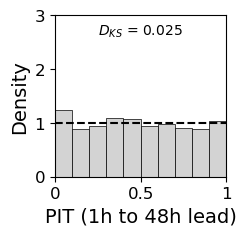

In [38]:
# solar asset
resource = 'solar'
type = 'asset'
description = 1
method = 'fusion'
score = 'FCS'

hyper_, envelope_, validation_ = _load_hyperparamerters(resource, method, type, score, description, 
                                                        path = path_to_validation)

# interval = 120
# lead = 12
# horizon = [0, 12, 24, 36, 48, 60][2]
interval = 144 
lead = 9
horizon = [0, 9, 18, 27, 36, 45][2]
# interval = 168 
# lead = 6
# horizon = [0, 6, 12, 18, 24, 30][2]

pit_ = _load_pit(validation_, resource, method, type, interval, description, 
                 path = path_to_validation)

print(pit_.shape)

_fig, _ax = plt.subplots(1, 1, 
                        figsize = (2.3, 2.25), 
                        layout  = "constrained")

_plot_PIT(_ax, pit_[:, horizon:(horizon + lead)].flatten(), 
          bins = 10,
          xlabel = 'PIT (1h to 48h lead)')

# plt.savefig(path_to_images + f"/PIT-{resource}-{method}-{type}-{interval}-{horizon}.pdf", 
#             bbox_inches="tight")


plt.show()

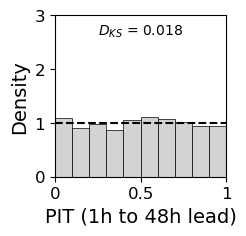

In [36]:
# wind asset
resource = 'wind'
method = 'fusion'
type = 'asset'
description = 5
score = 'FCS'

hyper_, envelope_, validation_ = _load_hyperparamerters(resource, method, type, score, description, 
                                                        path = path_to_validation)

# interval = 72
# lead = 36
# horizon = [0, 36, 72, 108, 144, 180][2]
interval = 144
lead = 24
horizon = [0, 24, 48, 72, 96, 120][2]
# interval = 216
# lead = 12
# horizon = [0, 12, 24, 36, 48, 60][2]

pit_ = _load_pit(validation_, resource, method, type, interval, description, 
                 path = path_to_validation)

_fig, _ax = plt.subplots(1, 1, 
                        figsize = (2.3, 2.25), 
                        layout  = "constrained")

_plot_PIT(_ax, pit_[:, horizon:(horizon + lead)].flatten(), 
          bins = 10,
          xlabel = 'PIT (1h to 48h lead)')

# plt.savefig(path_to_images + f"/PIT-{resource}-{method}-{type}-{interval}-{horizon}.pdf", 
#             bbox_inches="tight")

plt.show()

(5400, 48)


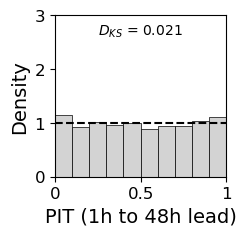

In [37]:
# wind zone
resource = 'wind'
type = 'zone'
description = 11
method = 'fusion'
score = 'FCS'

interval = 12

hyper_, envelope_, validation_ = _load_hyperparamerters(resource, method, type, score, description, 
                                                        path = path_to_validation)

# interval = 6
interval = 12
# interval = 18

lead = 6
horizon = [0, 6, 12, 18, 24, 30][2]


pit_ = _load_pit(validation_, resource, method, type, interval, description, 
                 path = path_to_validation)
print(pit_.shape)

_fig, _ax = plt.subplots(1, 1, 
                        figsize = (2.3, 2.25), 
                        layout  = "constrained")


_plot_PIT(_ax, pit_[:, horizon:(horizon + lead)].flatten(), 
          bins = 10,
          xlabel = 'PIT (1h to 48h lead)')

# plt.savefig(path_to_images + f"/PIT-{resource}-{method}-{type}-{interval}-{horizon}.pdf", 
#             bbox_inches="tight")

plt.show()